0. 라이브러리 설치

In [1]:
! pip install sentencepiece
! pip install tqdm
! conda install -c conda-forge ipywidgets
! jupyter nbextension enable --py widgetsnbextension
! pip install torchsummary

/bin/bash: line 1: conda: command not found
Enabling notebook extension jupyter-js-widgets/extension...
      - Validating: OK


In [2]:
# 데이터 준비
!wget https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip

--2026-07-20 01:38:16--  https://d3s0tskafalll9.cloudfront.net/media/documents/kowiki.txt.zip
Resolving d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)... 13.249.182.60, 13.249.182.118, 13.249.182.95, ...
Connecting to d3s0tskafalll9.cloudfront.net (d3s0tskafalll9.cloudfront.net)|13.249.182.60|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 243123354 (232M) [application/zip]
Saving to: ‘kowiki.txt.zip’

kowiki.txt.zip      100%[===================>] 231.86M   229MB/s    in 1.0s    

2026-07-20 01:38:17 (229 MB/s) - ‘kowiki.txt.zip’ saved [243123354/243123354]



1. Tokenizer 준비

In [3]:
import sentencepiece as spm
import zipfile
import os

# 1. 압축 해제
with zipfile.ZipFile('kowiki.txt.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

corpus_file = 'kowiki.txt'
print(f"코퍼스 파일 크기: {os.path.getsize(corpus_file) / (1024*1024):.2f} MB")

# 2. SentencePiece 학습 파라미터 설정
# BERT에서 사용하는 주요 특수 토큰
# - [PAD]: 패딩
# - [UNK]: 미등록 단어
# - [CLS]: 문장 시작(분류 토큰)
# - [SEP]: 문장 구분
# - [MASK]: MLM 마스킹 토큰

prefix = 'kowiki_spm'      # 생성될 모델 파일 접두어 (kowiki_spm.model / kowiki_spm.vocab)
vocab_size = 8000

spm.SentencePieceTrainer.train(
    input=corpus_file,
    model_prefix=prefix,
    vocab_size=vocab_size,
    model_type='bpe',              # BERT 계열은 보통 bpe 또는 unigram 사용
    character_coverage=0.9995,     # 한글 포함 다양한 문자 커버리지 확보
    max_sentence_length=999999,
    pad_id=0, pad_piece='[PAD]',
    unk_id=1, unk_piece='[UNK]',
    bos_id=2, bos_piece='[CLS]',
    eos_id=3, eos_piece='[SEP]',
    user_defined_symbols=['[MASK]']  # MLM 마스킹용 특수 토큰 추가
)

print("SentencePiece 모델 학습 완료!")
print(f" - {prefix}.model")
print(f" - {prefix}.vocab")

코퍼스 파일 크기: 635.67 MB
SentencePiece 모델 학습 완료!
 - kowiki_spm.model
 - kowiki_spm.vocab


In [4]:
# 3. 학습된 모델 로드 및 확인
sp = spm.SentencePieceProcessor()
sp.load(f'{prefix}.model')

print("Vocab size:", sp.get_piece_size())

# 특수 토큰 ID 확인
for token in ['[PAD]', '[UNK]', '[CLS]', '[SEP]', '[MASK]']:
    print(f"{token} -> id: {sp.piece_to_id(token)}")

# 간단한 토크나이징 테스트
sample = "나무위키는 다양한 정보를 담고 있는 위키 사이트입니다."
print("\n토큰화 결과:", sp.encode_as_pieces(sample))
print("ID 변환 결과:", sp.encode_as_ids(sample))

Vocab size: 8000
[PAD] -> id: 0
[UNK] -> id: 1
[CLS] -> id: 2
[SEP] -> id: 3
[MASK] -> id: 4

토큰화 결과: ['▁나무', '위', '키는', '▁다양한', '▁정보를', '▁담', '고', '▁있는', '▁위', '키', '▁사이', '트', '입', '니다', '.']
ID 변환 결과: [2389, 3656, 1359, 972, 3201, 646, 3602, 87, 43, 3786, 326, 3670, 3802, 1200, 3592]


# **2. 데이터 전처리**

**MASK 생성**

In [6]:
import sentencepiece as spm
import random
import numpy as np

# 1. SentencePiece 모델 로드
sp = spm.SentencePieceProcessor()
sp.load('kowiki_spm.model')

vocab_size = sp.get_piece_size()

PAD_ID = sp.piece_to_id('[PAD]')
UNK_ID = sp.piece_to_id('[UNK]')
CLS_ID = sp.piece_to_id('[CLS]')
SEP_ID = sp.piece_to_id('[SEP]')
MASK_ID = sp.piece_to_id('[MASK]')

# 특수 토큰들은 마스킹 대상에서 제외
SPECIAL_IDS = {PAD_ID, UNK_ID, CLS_ID, SEP_ID, MASK_ID}


def create_mlm_mask(token_ids, mask_prob=0.15):
    """
    BERT MLM 방식으로 토큰 시퀀스를 마스킹
    - 전체 토큰 중 15%를 마스킹 대상으로 선정
      - 그 중 80% -> [MASK] 토큰으로 치환
      - 10% -> 랜덤 토큰으로 치환
      - 10% -> 원래 토큰 그대로 유지 (단, 라벨은 존재)

    Returns:
        input_ids: 마스킹 처리된 입력 시퀀스
        labels: 마스킹 위치는 원래 토큰 id, 그 외는 -100(loss 계산 제외)
    """
    input_ids = list(token_ids)
    labels = [-100] * len(input_ids)

    # 마스킹 후보 인덱스 (특수 토큰 제외)
    candidate_indices = [
        i for i, tok in enumerate(input_ids) if tok not in SPECIAL_IDS
    ]

    n_mask = max(1, int(round(len(candidate_indices) * mask_prob)))
    mask_indices = random.sample(candidate_indices, min(n_mask, len(candidate_indices)))

    for idx in mask_indices:
        original_token = input_ids[idx]
        labels[idx] = original_token  # 정답 라벨 저장

        prob = random.random()
        if prob < 0.8:
            # 80% -> [MASK]
            input_ids[idx] = MASK_ID
        elif prob < 0.9:
            # 10% -> 랜덤 토큰 (특수 토큰 제외한 범위에서 선택)
            random_token = random.randint(0, vocab_size - 1)
            while random_token in SPECIAL_IDS:
                random_token = random.randint(0, vocab_size - 1)
            input_ids[idx] = random_token
        else:
            # 10% -> 원래 토큰 유지
            input_ids[idx] = original_token

    return input_ids, labels

In [8]:
# 2. 코퍼스를 문장 단위로 인코딩 후 [CLS], [SEP] 추가하여 MLM 데이터 생성

def build_mlm_dataset(corpus_path, sp, max_seq_len=128, mask_prob=0.15, limit_lines=None):
    dataset = []

    with open(corpus_path, 'r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if limit_lines is not None and i >= limit_lines:
                break

            line = line.strip()
            if not line:
                continue

            token_ids = sp.encode_as_ids(line)

            # 길이 제한 (CLS, SEP 자리 확보)
            token_ids = token_ids[:max_seq_len - 2]

            # [CLS] token [SEP]
            token_ids = [CLS_ID] + token_ids + [SEP_ID]

            input_ids, labels = create_mlm_mask(token_ids, mask_prob=mask_prob)

            dataset.append({
                'input_ids': input_ids,
                'labels': labels
            })

    return dataset


# 실행 (테스트로 일부만 먼저 확인, 전체 실행 시 limit_lines=None)
mlm_dataset = build_mlm_dataset('kowiki.txt', sp, max_seq_len=128, mask_prob=0.15, limit_lines=1000)

print(f"생성된 데이터 개수: {len(mlm_dataset)}")

생성된 데이터 개수: 868


In [9]:
# 3. 결과 확인
sample = mlm_dataset[0]

print("Input IDs :", sample['input_ids'])
print("Labels    :", sample['labels'])
print()

print("Input tokens :", [sp.id_to_piece(i) for i in sample['input_ids']])
print()

masked_positions = [i for i, l in enumerate(sample['labels']) if l != -100]
print(f"마스킹된 토큰 개수: {len(masked_positions)} / {len(sample['input_ids'])}")

for pos in masked_positions:
    original = sp.id_to_piece(sample['labels'][pos])
    replaced = sp.id_to_piece(sample['input_ids'][pos])
    print(f" - 위치 {pos}: 원본='{original}' -> 변환후='{replaced}'")

Input IDs : [2, 16, 3679, 205, 4, 3]
Labels    : [-100, -100, -100, -100, 3707, -100]

Input tokens : ['[CLS]', '▁지', '미', '▁카', '[MASK]', '[SEP]']

마스킹된 토큰 개수: 1 / 6
 - 위치 4: 원본='터' -> 변환후='[MASK]'


**NSP pair 생성**

In [10]:
# 1. 문서 단위로 코퍼스 로드 (NSP를 위해 필요 - 새로 추가하는 부분)
def load_documents(corpus_path):
    documents = []
    current_doc = []

    with open(corpus_path, 'r', encoding='utf-8') as f:
        for line in f:
            line = line.strip()
            if not line:
                if current_doc:
                    documents.append(current_doc)
                    current_doc = []
            else:
                current_doc.append(line)

    if current_doc:
        documents.append(current_doc)

    documents = [doc for doc in documents if len(doc) >= 2]
    return documents


documents = load_documents('kowiki.txt')
print(f"문서 개수: {len(documents)}")

문서 개수: 498198


In [11]:
# 2. NSP pair 선택 함수 (새로 추가하는 부분)
def get_nsp_pair(documents, doc_idx, sent_idx):
    current_doc = documents[doc_idx]
    sent_a = current_doc[sent_idx]

    is_next = random.random() < 0.5

    if is_next and sent_idx + 1 < len(current_doc):
        sent_b = current_doc[sent_idx + 1]
    else:
        is_next = False
        random_doc_idx = random.randint(0, len(documents) - 1)
        while random_doc_idx == doc_idx and len(documents) > 1:
            random_doc_idx = random.randint(0, len(documents) - 1)
        sent_b = random.choice(documents[random_doc_idx])

    return sent_a, sent_b, is_next

In [12]:
# 3. NSP + MLM 통합 데이터 생성 함수 (새로 추가하는 부분)
# create_mlm_mask는 이미 만들어둔 함수를 그대로 호출해서 씁니다

def build_bert_pretrain_data(documents, sp, max_seq_len=128, mask_prob=0.15, num_samples=None):
    dataset = []

    index_pairs = []
    for doc_idx, doc in enumerate(documents):
        for sent_idx in range(len(doc) - 1):
            index_pairs.append((doc_idx, sent_idx))

    if num_samples is not None:
        index_pairs = random.sample(index_pairs, min(num_samples, len(index_pairs)))

    for doc_idx, sent_idx in index_pairs:
        sent_a, sent_b, is_next = get_nsp_pair(documents, doc_idx, sent_idx)

        max_tokens_for_pair = max_seq_len - 3
        half_len = max_tokens_for_pair // 2

        tokens_a = sp.encode_as_ids(sent_a)[:half_len]
        tokens_b = sp.encode_as_ids(sent_b)[:max_tokens_for_pair - len(tokens_a)]

        input_ids = [CLS_ID] + tokens_a + [SEP_ID] + tokens_b + [SEP_ID]
        segment_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

        masked_input_ids, mlm_labels = create_mlm_mask(input_ids, mask_prob=mask_prob)  # 기존 함수 재사용

        dataset.append({
            'input_ids': masked_input_ids,
            'labels': mlm_labels,
            'segment_ids': segment_ids,
            'is_next': int(is_next)
        })

    return dataset


pretrain_dataset = build_bert_pretrain_data(documents, sp, max_seq_len=128, mask_prob=0.15, num_samples=1000)
print(f"생성된 pretrain 샘플 개수: {len(pretrain_dataset)}")

생성된 pretrain 샘플 개수: 1000


**데이터셋 완성**

In [13]:
import numpy as np
import json
import random

# 1. 전체 샘플 개수와 시퀀스 길이를 먼저 확정 (memmap은 크기를 미리 알아야 함)

max_seq_len = 128

# NSP pair로 만들 수 있는 전체 (문서, 문장) 인덱스 목록
index_pairs = []
for doc_idx, doc in enumerate(documents):
    for sent_idx in range(len(doc) - 1):
        index_pairs.append((doc_idx, sent_idx))

num_samples = len(index_pairs)  # 전체 데이터 사용. 일부만 쓰려면 여기서 슬라이싱
print(f"총 샘플 개수: {num_samples}")

총 샘플 개수: 1948125


In [14]:
# 2. np.memmap으로 디스크에 배열 생성
# 한 번에 메모리에 올리지 않고, 디스크에 직접 쓰고 읽는 방식

input_ids_mm   = np.memmap('input_ids.mmap',   dtype=np.int32, mode='w+', shape=(num_samples, max_seq_len))
labels_mm      = np.memmap('labels.mmap',      dtype=np.int32, mode='w+', shape=(num_samples, max_seq_len))
segment_ids_mm = np.memmap('segment_ids.mmap', dtype=np.int32, mode='w+', shape=(num_samples, max_seq_len))
attn_mask_mm   = np.memmap('attn_mask.mmap',   dtype=np.int32, mode='w+', shape=(num_samples, max_seq_len))
is_next_mm     = np.memmap('is_next.mmap',     dtype=np.int32, mode='w+', shape=(num_samples,))

# 모든 배열을 PAD_ID(=0)로 초기화 (labels는 -100으로 초기화해야 loss 계산에서 제외됨)
input_ids_mm[:]   = PAD_ID
labels_mm[:]      = -100
segment_ids_mm[:] = 0
attn_mask_mm[:]   = 0

In [15]:
# 3. 샘플을 하나씩 만들어서 memmap 배열에 채워 넣기
# (전체를 리스트에 쌓지 않고 바로바로 디스크에 기록 -> 메모리 절약)

for i, (doc_idx, sent_idx) in enumerate(index_pairs):
    sent_a, sent_b, is_next = get_nsp_pair(documents, doc_idx, sent_idx)

    max_tokens_for_pair = max_seq_len - 3
    half_len = max_tokens_for_pair // 2

    tokens_a = sp.encode_as_ids(sent_a)[:half_len]
    tokens_b = sp.encode_as_ids(sent_b)[:max_tokens_for_pair - len(tokens_a)]

    ids = [CLS_ID] + tokens_a + [SEP_ID] + tokens_b + [SEP_ID]
    segs = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

    masked_ids, mlm_labels = create_mlm_mask(ids, mask_prob=0.15)

    seq_len = len(masked_ids)  # max_seq_len 이하로 자동으로 잘려있음

    input_ids_mm[i, :seq_len]   = masked_ids
    labels_mm[i, :seq_len]      = mlm_labels
    segment_ids_mm[i, :seq_len] = segs
    attn_mask_mm[i, :seq_len]   = 1          # 실제 토큰 위치는 1, 패딩은 0
    is_next_mm[i]                = int(is_next)

    if (i + 1) % 10000 == 0:
        print(f"{i + 1}/{num_samples} 완료")

# 디스크에 즉시 반영
input_ids_mm.flush()
labels_mm.flush()
segment_ids_mm.flush()
attn_mask_mm.flush()
is_next_mm.flush()

print("memmap 배열 생성 완료")

10000/1948125 완료
20000/1948125 완료
30000/1948125 완료
40000/1948125 완료
50000/1948125 완료
60000/1948125 완료
70000/1948125 완료
80000/1948125 완료
90000/1948125 완료
100000/1948125 완료
110000/1948125 완료
120000/1948125 완료
130000/1948125 완료
140000/1948125 완료
150000/1948125 완료
160000/1948125 완료
170000/1948125 완료
180000/1948125 완료
190000/1948125 완료
200000/1948125 완료
210000/1948125 완료
220000/1948125 완료
230000/1948125 완료
240000/1948125 완료
250000/1948125 완료
260000/1948125 완료
270000/1948125 완료
280000/1948125 완료
290000/1948125 완료
300000/1948125 완료
310000/1948125 완료
320000/1948125 완료
330000/1948125 완료
340000/1948125 완료
350000/1948125 완료
360000/1948125 완료
370000/1948125 완료
380000/1948125 완료
390000/1948125 완료
400000/1948125 완료
410000/1948125 완료
420000/1948125 완료
430000/1948125 완료
440000/1948125 완료
450000/1948125 완료
460000/1948125 완료
470000/1948125 완료
480000/1948125 완료
490000/1948125 완료
500000/1948125 완료
510000/1948125 완료
520000/1948125 완료
530000/1948125 완료
540000/1948125 완료
550000/1948125 완료
560000/1948125 완료
5

In [16]:
# 4. memmap 배열을 한 줄씩 순회하며 JSON Lines(.jsonl) 형식으로 저장
# 전체를 리스트로 모으지 않고, 파일에 바로바로 write -> 메모리 사용 최소화

output_path = 'bert_pretrain_data.jsonl'

with open(output_path, 'w', encoding='utf-8') as f:
    for i in range(num_samples):
        sample = {
            'input_ids':   input_ids_mm[i].tolist(),
            'labels':      labels_mm[i].tolist(),
            'segment_ids': segment_ids_mm[i].tolist(),
            'attention_mask': attn_mask_mm[i].tolist(),
            'is_next':     int(is_next_mm[i])
        }
        f.write(json.dumps(sample, ensure_ascii=False) + '\n')

        if (i + 1) % 10000 == 0:
            print(f"저장 진행: {i + 1}/{num_samples}")

print(f"저장 완료: {output_path}")

저장 진행: 10000/1948125
저장 진행: 20000/1948125
저장 진행: 30000/1948125
저장 진행: 40000/1948125
저장 진행: 50000/1948125
저장 진행: 60000/1948125
저장 진행: 70000/1948125
저장 진행: 80000/1948125
저장 진행: 90000/1948125
저장 진행: 100000/1948125
저장 진행: 110000/1948125
저장 진행: 120000/1948125
저장 진행: 130000/1948125
저장 진행: 140000/1948125
저장 진행: 150000/1948125
저장 진행: 160000/1948125
저장 진행: 170000/1948125
저장 진행: 180000/1948125
저장 진행: 190000/1948125
저장 진행: 200000/1948125
저장 진행: 210000/1948125
저장 진행: 220000/1948125
저장 진행: 230000/1948125
저장 진행: 240000/1948125
저장 진행: 250000/1948125
저장 진행: 260000/1948125
저장 진행: 270000/1948125
저장 진행: 280000/1948125
저장 진행: 290000/1948125
저장 진행: 300000/1948125
저장 진행: 310000/1948125
저장 진행: 320000/1948125
저장 진행: 330000/1948125
저장 진행: 340000/1948125
저장 진행: 350000/1948125
저장 진행: 360000/1948125
저장 진행: 370000/1948125
저장 진행: 380000/1948125
저장 진행: 390000/1948125
저장 진행: 400000/1948125
저장 진행: 410000/1948125
저장 진행: 420000/1948125
저장 진행: 430000/1948125
저장 진행: 440000/1948125
저장 진행: 450000/1948125
저장 진행: 460000/19481

In [17]:
# 5. 저장 결과 확인 (파일 첫 줄만 읽어서 확인)

with open(output_path, 'r', encoding='utf-8') as f:
    first_line = f.readline()
    sample = json.loads(first_line)

print("Input IDs      :", sample['input_ids'][:20], "...")
print("Segment IDs    :", sample['segment_ids'][:20], "...")
print("Attention Mask :", sample['attention_mask'][:20], "...")
print("Is Next        :", sample['is_next'])

import os
print(f"\n최종 파일 크기: {os.path.getsize(output_path) / (1024*1024):.2f} MB")

Input IDs      : [2, 16, 3679, 4, 3707, 3, 3322, 1040, 102, 4, 3679, 3711, 205, 3707, 4, 3415, 414, 808, 3659, 1906] ...
Segment IDs    : [0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...
Attention Mask : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1] ...
Is Next        : 1

최종 파일 크기: 4032.02 MB


# **3. BERT 모델 설계**

In [18]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
import math
import json


# 1. 유틸리티 함수


def get_pad_mask(seq, pad_id=0):
    """
    패딩 토큰 위치를 마스킹 (attention에서 무시하기 위함)
    seq: (batch_size, seq_len)
    return: (batch_size, 1, 1, seq_len) - 1: 실제 토큰, 0: 패딩
    """
    mask = (seq != pad_id).unsqueeze(1).unsqueeze(2)  # broadcasting을 위한 차원 확장
    return mask.float()


def get_ahead_mask(seq_len, device='cpu'):
    """
    미래 토큰을 보지 못하게 막는 마스크 (GPT류에서 주로 사용)
    BERT는 양방향이라 encoder에는 직접 안 쓰지만, 유틸리티로 함께 준비
    return: (seq_len, seq_len) - 하삼각행렬(1: 볼 수 있음, 0: 못 봄)
    """
    mask = torch.tril(torch.ones(seq_len, seq_len, device=device))
    return mask


def gelu(x):
    """
    BERT 논문에서 사용하는 GELU activation
    (erf 기반 정확한 버전)
    """
    return 0.5 * x * (1.0 + torch.erf(x / math.sqrt(2.0)))


def initializer(std=0.02):
    """
    BERT 논문 기본값(std=0.02)을 따르는 정규분포 파라미터 초기화 함수
    nn.Module.apply()와 함께 사용
    """
    def _init(module):
        if isinstance(module, (nn.Linear, nn.Embedding)):
            module.weight.data.normal_(mean=0.0, std=std)
            if isinstance(module, nn.Linear) and module.bias is not None:
                module.bias.data.zero_()
        elif isinstance(module, nn.LayerNorm):
            module.bias.data.zero_()
            module.weight.data.fill_(1.0)
    return _init


class Config:
    """
    json 형태의 설정값을 속성처럼 접근 가능한 객체로 변환
    ex) config.hidden_size, config.num_layers ...
    """
    def __init__(self, config_dict):
        for key, value in config_dict.items():
            setattr(self, key, value)

    @classmethod
    def from_json(cls, json_path):
        with open(json_path, 'r', encoding='utf-8') as f:
            config_dict = json.load(f)
        return cls(config_dict)

    def to_dict(self):
        return self.__dict__

    def __repr__(self):
        return json.dumps(self.to_dict(), indent=2, ensure_ascii=False)


# 예시 config (실제로는 json 파일로 저장해두고 Config.from_json으로 불러오면 됨)
config_dict = {
    "vocab_size": 8000,
    "hidden_size": 256,
    "num_hidden_layers": 4,
    "num_attention_heads": 4,
    "intermediate_size": 1024,
    "max_seq_len": 128,
    "dropout_prob": 0.1,
    "pad_id": 0,
    "type_vocab_size": 2,      # segment 종류 (0, 1)
    "layer_norm_eps": 1e-12
}

config = Config(config_dict)
print(config)

{
  "vocab_size": 8000,
  "hidden_size": 256,
  "num_hidden_layers": 4,
  "num_attention_heads": 4,
  "intermediate_size": 1024,
  "max_seq_len": 128,
  "dropout_prob": 0.1,
  "pad_id": 0,
  "type_vocab_size": 2,
  "layer_norm_eps": 1e-12
}


In [19]:
# 2. Embedding 레이어

class BERTEmbedding(nn.Module):
    """
    Token Embedding + Position Embedding + Segment Embedding
    -> LayerNorm -> Dropout
    """
    def __init__(self, config):
        super().__init__()
        self.token_embedding = nn.Embedding(config.vocab_size, config.hidden_size, padding_idx=config.pad_id)
        self.position_embedding = nn.Embedding(config.max_seq_len, config.hidden_size)
        self.segment_embedding = nn.Embedding(config.type_vocab_size, config.hidden_size)

        self.layer_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.dropout = nn.Dropout(config.dropout_prob)

    def forward(self, input_ids, segment_ids):
        seq_len = input_ids.size(1)
        position_ids = torch.arange(seq_len, dtype=torch.long, device=input_ids.device)
        position_ids = position_ids.unsqueeze(0).expand_as(input_ids)  # (batch, seq_len)

        embeddings = (
            self.token_embedding(input_ids)
            + self.position_embedding(position_ids)
            + self.segment_embedding(segment_ids)
        )
        embeddings = self.layer_norm(embeddings)
        embeddings = self.dropout(embeddings)
        return embeddings

In [20]:
# 3. Transformer Encoder 레이어 (Multi-Head Attention + FFN)

class MultiHeadAttention(nn.Module):
    def __init__(self, config):
        super().__init__()
        assert config.hidden_size % config.num_attention_heads == 0

        self.num_heads = config.num_attention_heads
        self.head_dim = config.hidden_size // config.num_attention_heads

        self.query = nn.Linear(config.hidden_size, config.hidden_size)
        self.key = nn.Linear(config.hidden_size, config.hidden_size)
        self.value = nn.Linear(config.hidden_size, config.hidden_size)
        self.out = nn.Linear(config.hidden_size, config.hidden_size)

        self.dropout = nn.Dropout(config.dropout_prob)

    def split_heads(self, x, batch_size):
        # (batch, seq_len, hidden) -> (batch, num_heads, seq_len, head_dim)
        x = x.view(batch_size, -1, self.num_heads, self.head_dim)
        return x.permute(0, 2, 1, 3)

    def forward(self, x, pad_mask=None):
        batch_size = x.size(0)

        q = self.split_heads(self.query(x), batch_size)
        k = self.split_heads(self.key(x), batch_size)
        v = self.split_heads(self.value(x), batch_size)

        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.head_dim)

        if pad_mask is not None:
            # pad_mask: (batch, 1, 1, seq_len), 0인 곳을 매우 작은 값으로 채워 softmax에서 무시되게 함
            scores = scores.masked_fill(pad_mask == 0, float('-inf'))

        attn_probs = F.softmax(scores, dim=-1)
        attn_probs = self.dropout(attn_probs)

        context = torch.matmul(attn_probs, v)  # (batch, num_heads, seq_len, head_dim)
        context = context.permute(0, 2, 1, 3).contiguous()
        context = context.view(batch_size, -1, self.num_heads * self.head_dim)

        return self.out(context)


class FeedForward(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.fc1 = nn.Linear(config.hidden_size, config.intermediate_size)
        self.fc2 = nn.Linear(config.intermediate_size, config.hidden_size)
        self.dropout = nn.Dropout(config.dropout_prob)

    def forward(self, x):
        x = gelu(self.fc1(x))   # BERT는 GELU 사용
        x = self.dropout(x)
        x = self.fc2(x)
        return x


class TransformerEncoderLayer(nn.Module):
    """
    Multi-Head Attention -> Add & Norm -> FeedForward -> Add & Norm
    """
    def __init__(self, config):
        super().__init__()
        self.attention = MultiHeadAttention(config)
        self.attn_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)

        self.ffn = FeedForward(config)
        self.ffn_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)

        self.dropout = nn.Dropout(config.dropout_prob)

    def forward(self, x, pad_mask=None):
        attn_out = self.attention(x, pad_mask)
        x = self.attn_norm(x + self.dropout(attn_out))  # residual connection

        ffn_out = self.ffn(x)
        x = self.ffn_norm(x + self.dropout(ffn_out))    # residual connection

        return x

In [21]:
# 4. BERT 본체 (Embedding + N개의 Encoder Layer)

class BERT(nn.Module):
    def __init__(self, config):
        super().__init__()
        self.embedding = BERTEmbedding(config)
        self.encoder_layers = nn.ModuleList(
            [TransformerEncoderLayer(config) for _ in range(config.num_hidden_layers)]
        )
        self.pad_id = config.pad_id

        self.apply(initializer(std=0.02))  # 전체 파라미터 초기화

    def forward(self, input_ids, segment_ids):
        pad_mask = get_pad_mask(input_ids, self.pad_id)  # (batch, 1, 1, seq_len)

        x = self.embedding(input_ids, segment_ids)

        for layer in self.encoder_layers:
            x = layer(x, pad_mask)

        return x  # (batch, seq_len, hidden_size) - 마지막 encoder layer의 출력

In [22]:
# 5. Pretrain용 BERT 모델 (MLM head + NSP head)

class BERTForPretraining(nn.Module):
    """
    BERT 본체 + MLM head + NSP head
    - MLM head: 각 토큰 위치에서 vocab 전체에 대한 확률 분포 예측
    - NSP head: [CLS] 토큰의 representation으로 IsNext 여부(2-class) 예측
    """
    def __init__(self, config):
        super().__init__()
        self.bert = BERT(config)

        # MLM head: hidden -> hidden -> vocab_size
        self.mlm_dense = nn.Linear(config.hidden_size, config.hidden_size)
        self.mlm_norm = nn.LayerNorm(config.hidden_size, eps=config.layer_norm_eps)
        self.mlm_decoder = nn.Linear(config.hidden_size, config.vocab_size)

        # MLM decoder의 weight를 token embedding과 공유 (BERT 논문 기법, weight tying)
        self.mlm_decoder.weight = self.bert.embedding.token_embedding.weight

        # NSP head: [CLS] representation -> 2-class 분류
        self.nsp_pooler = nn.Linear(config.hidden_size, config.hidden_size)
        self.nsp_classifier = nn.Linear(config.hidden_size, 2)

    def forward(self, input_ids, segment_ids):
        sequence_output = self.bert(input_ids, segment_ids)  # (batch, seq_len, hidden)

        # ---- MLM ----
        mlm_hidden = gelu(self.mlm_dense(sequence_output))
        mlm_hidden = self.mlm_norm(mlm_hidden)
        mlm_logits = self.mlm_decoder(mlm_hidden)  # (batch, seq_len, vocab_size)

        # ---- NSP ----
        cls_output = sequence_output[:, 0]  # [CLS] 토큰(첫 번째 위치) representation
        pooled_output = torch.tanh(self.nsp_pooler(cls_output))
        nsp_logits = self.nsp_classifier(pooled_output)  # (batch, 2)

        return mlm_logits, nsp_logits

In [23]:
# 6. 모델 생성 및 확인


model = BERTForPretraining(config)

total_params = sum(p.numel() for p in model.parameters())
print(f"전체 파라미터 개수: {total_params:,}")

# 더미 입력으로 forward 테스트
batch_size = 2
seq_len = 20

dummy_input_ids = torch.randint(0, config.vocab_size, (batch_size, seq_len))
dummy_segment_ids = torch.zeros(batch_size, seq_len, dtype=torch.long)

mlm_logits, nsp_logits = model(dummy_input_ids, dummy_segment_ids)

print("MLM logits shape:", mlm_logits.shape)  # (batch, seq_len, vocab_size)
print("NSP logits shape:", nsp_logits.shape)  # (batch, 2)

전체 파라미터 개수: 5,381,442
MLM logits shape: torch.Size([2, 20, 8000])
NSP logits shape: torch.Size([2, 2])


# **4. 모델학습: pretrain 진행**

In [24]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import numpy as np
import math


# 1. Dataset (기존 memmap 파일 재사용, 메모리에 전체를 올리지 않음)

class BERTPretrainDataset(Dataset):
    def __init__(self, num_samples, max_seq_len):
        # mode='r' -> 읽기 전용으로 열기 (메모리에 안 올라오고 필요한 부분만 디스크에서 읽음)
        self.input_ids   = np.memmap('input_ids.mmap',   dtype=np.int32, mode='r', shape=(num_samples, max_seq_len))
        self.labels      = np.memmap('labels.mmap',      dtype=np.int32, mode='r', shape=(num_samples, max_seq_len))
        self.segment_ids = np.memmap('segment_ids.mmap', dtype=np.int32, mode='r', shape=(num_samples, max_seq_len))
        self.attn_mask   = np.memmap('attn_mask.mmap',   dtype=np.int32, mode='r', shape=(num_samples, max_seq_len))
        self.is_next     = np.memmap('is_next.mmap',     dtype=np.int32, mode='r', shape=(num_samples,))
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        return {
            'input_ids':      torch.tensor(self.input_ids[idx],   dtype=torch.long),
            'labels':         torch.tensor(self.labels[idx],      dtype=torch.long),
            'segment_ids':    torch.tensor(self.segment_ids[idx], dtype=torch.long),
            'attention_mask': torch.tensor(self.attn_mask[idx],   dtype=torch.long),
            'is_next':        torch.tensor(self.is_next[idx],     dtype=torch.long),
        }


dataset = BERTPretrainDataset(num_samples, max_seq_len)
print(f"데이터셋 크기: {len(dataset)}")

# 배치 사이즈: 시퀀스 길이(128)와 hidden_size 등을 고려해 GPU 메모리에 맞게 설정
# 코랩 무료 GPU(T4, ~15GB) 기준 32 정도가 안전한 시작값. OOM 발생 시 낮추세요.
batch_size = 32

train_loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
print(f"배치 개수: {len(train_loader)}")

데이터셋 크기: 1948125
배치 개수: 60879


In [25]:
# 2. Loss / Accuracy 함수 정의

mlm_loss_fn = nn.CrossEntropyLoss(ignore_index=-100)  # 마스킹 안 된 위치(-100)는 자동 무시
nsp_loss_fn = nn.CrossEntropyLoss()


def compute_loss(mlm_logits, nsp_logits, mlm_labels, nsp_labels):
    """
    MLM loss + NSP loss를 더한 총 loss (BERT는 두 태스크를 동시에 학습)
    """
    mlm_loss = mlm_loss_fn(mlm_logits.view(-1, mlm_logits.size(-1)), mlm_labels.view(-1))
    nsp_loss = nsp_loss_fn(nsp_logits, nsp_labels)
    total_loss = mlm_loss + nsp_loss
    return total_loss, mlm_loss, nsp_loss


def compute_mlm_accuracy(mlm_logits, mlm_labels):
    """
    마스킹된 위치(labels != -100)에서만 정확도 계산
    """
    preds = mlm_logits.argmax(dim=-1)
    mask = (mlm_labels != -100)

    if mask.sum() == 0:
        return torch.tensor(0.0)

    correct = ((preds == mlm_labels) & mask).sum().float()
    total = mask.sum().float()
    return correct / total


def compute_nsp_accuracy(nsp_logits, nsp_labels):
    preds = nsp_logits.argmax(dim=-1)
    correct = (preds == nsp_labels).sum().float()
    return correct / nsp_labels.size(0)

In [26]:
# 3. Learning Rate 스케줄링 (BERT 논문 방식: linear warmup + linear decay)

def get_linear_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps):
    """
    처음 num_warmup_steps 동안 lr을 0 -> 설정값까지 선형 증가
    이후 num_training_steps까지 선형으로 0에 가깝게 감소
    """
    def lr_lambda(current_step):
        if current_step < num_warmup_steps:
            return float(current_step) / float(max(1, num_warmup_steps))
        progress = float(current_step - num_warmup_steps) / float(max(1, num_training_steps - num_warmup_steps))
        return max(0.0, 1.0 - progress)

    return torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

In [27]:
# 4. 학습 준비 (device, optimizer, scheduler)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"학습 device: {device}")

model = model.to(device)

learning_rate = 1e-4
num_epochs = 10
num_training_steps = len(train_loader) * num_epochs
num_warmup_steps = int(num_training_steps * 0.1)  # 전체 스텝의 10%를 warmup으로 사용 (BERT 논문 기본값)

optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate, weight_decay=0.01)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps, num_training_steps)

print(f"총 학습 스텝: {num_training_steps}, warmup 스텝: {num_warmup_steps}")

학습 device: cuda
총 학습 스텝: 608790, warmup 스텝: 60879


In [28]:
# 5. 학습 루프 (10 Epoch)

model.train()

for epoch in range(1, num_epochs + 1):
    epoch_loss = 0.0
    epoch_mlm_acc = 0.0
    epoch_nsp_acc = 0.0

    for step, batch in enumerate(train_loader):
        input_ids   = batch['input_ids'].to(device)
        segment_ids = batch['segment_ids'].to(device)
        mlm_labels  = batch['labels'].to(device)
        nsp_labels  = batch['is_next'].to(device)

        optimizer.zero_grad()

        mlm_logits, nsp_logits = model(input_ids, segment_ids)

        loss, mlm_loss, nsp_loss = compute_loss(mlm_logits, nsp_logits, mlm_labels, nsp_labels)

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient explosion 방지
        optimizer.step()
        scheduler.step()

        mlm_acc = compute_mlm_accuracy(mlm_logits, mlm_labels)
        nsp_acc = compute_nsp_accuracy(nsp_logits, nsp_labels)

        epoch_loss += loss.item()
        epoch_mlm_acc += mlm_acc.item()
        epoch_nsp_acc += nsp_acc.item()

        if (step + 1) % 100 == 0:
            current_lr = scheduler.get_last_lr()[0]
            print(f"[Epoch {epoch}] Step {step+1}/{len(train_loader)} "
                  f"| Loss: {loss.item():.4f} (MLM: {mlm_loss.item():.4f}, NSP: {nsp_loss.item():.4f}) "
                  f"| MLM Acc: {mlm_acc.item():.4f} | NSP Acc: {nsp_acc.item():.4f} | LR: {current_lr:.2e}")

    avg_loss = epoch_loss / len(train_loader)
    avg_mlm_acc = epoch_mlm_acc / len(train_loader)
    avg_nsp_acc = epoch_nsp_acc / len(train_loader)

    print(f"\n=== Epoch {epoch} 완료 ===")
    print(f"평균 Loss: {avg_loss:.4f} | 평균 MLM Acc: {avg_mlm_acc:.4f} | 평균 NSP Acc: {avg_nsp_acc:.4f}\n")

    # 매 epoch마다 체크포인트 저장
    torch.save({
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': avg_loss,
    }, f'bert_pretrain_epoch{epoch}.pt')

print("전체 학습 완료!")

스트리밍 출력 내용이 길어서 마지막 5000줄이 삭제되었습니다.
[Epoch 2] Step 51000/60879 | Loss: 3.7173 (MLM: 3.6480, NSP: 0.0692) | MLM Acc: 0.3324 | NSP Acc: 0.9688 | LR: 9.07e-05
[Epoch 2] Step 51100/60879 | Loss: 3.3147 (MLM: 3.2692, NSP: 0.0455) | MLM Acc: 0.3944 | NSP Acc: 1.0000 | LR: 9.07e-05
[Epoch 2] Step 51200/60879 | Loss: 3.5547 (MLM: 3.3378, NSP: 0.2169) | MLM Acc: 0.3718 | NSP Acc: 0.8750 | LR: 9.07e-05
[Epoch 2] Step 51300/60879 | Loss: 3.6271 (MLM: 3.3896, NSP: 0.2375) | MLM Acc: 0.3774 | NSP Acc: 0.9062 | LR: 9.06e-05
[Epoch 2] Step 51400/60879 | Loss: 3.4962 (MLM: 3.4232, NSP: 0.0731) | MLM Acc: 0.3800 | NSP Acc: 0.9688 | LR: 9.06e-05
[Epoch 2] Step 51500/60879 | Loss: 3.5239 (MLM: 3.4448, NSP: 0.0791) | MLM Acc: 0.3860 | NSP Acc: 0.9688 | LR: 9.06e-05
[Epoch 2] Step 51600/60879 | Loss: 3.3124 (MLM: 3.1860, NSP: 0.1263) | MLM Acc: 0.4144 | NSP Acc: 0.9062 | LR: 9.06e-05
[Epoch 2] Step 51700/60879 | Loss: 3.4553 (MLM: 3.3133, NSP: 0.1420) | MLM Acc: 0.4014 | NSP Acc: 0.9062 | LR: 9.06e-05
[Epo

# **5. 프로젝트 결과**

In [37]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [38]:
import os
print("마운트 여부:", os.path.exists('/content/drive/MyDrive'))

마운트 여부: True


In [39]:
import shutil

drive_checkpoint_dir = '/content/drive/MyDrive/bert_pretrain_checkpoints'
os.makedirs(drive_checkpoint_dir, exist_ok=True)

local_ckpts = [f for f in os.listdir('/content') if f.startswith('bert_pretrain_epoch') and f.endswith('.pt')]

for f in sorted(local_ckpts):
    src = os.path.join('/content', f)
    dst = os.path.join(drive_checkpoint_dir, f)
    shutil.copy(src, dst)
    print(f"복사 완료: {f}")

print("\n드라이브 내 최종 파일 목록:", sorted(os.listdir(drive_checkpoint_dir)))

복사 완료: bert_pretrain_epoch1.pt
복사 완료: bert_pretrain_epoch10.pt
복사 완료: bert_pretrain_epoch2.pt
복사 완료: bert_pretrain_epoch3.pt
복사 완료: bert_pretrain_epoch4.pt
복사 완료: bert_pretrain_epoch5.pt
복사 완료: bert_pretrain_epoch6.pt
복사 완료: bert_pretrain_epoch7.pt
복사 완료: bert_pretrain_epoch8.pt
복사 완료: bert_pretrain_epoch9.pt

드라이브 내 최종 파일 목록: ['bert_pretrain_epoch1.pt', 'bert_pretrain_epoch10.pt', 'bert_pretrain_epoch2.pt', 'bert_pretrain_epoch3.pt', 'bert_pretrain_epoch4.pt', 'bert_pretrain_epoch5.pt', 'bert_pretrain_epoch6.pt', 'bert_pretrain_epoch7.pt', 'bert_pretrain_epoch8.pt', 'bert_pretrain_epoch9.pt']


In [40]:
checkpoint_dir = '/content/drive/MyDrive/bert_pretrain_checkpoints'

In [41]:
full_history = {'loss': [], 'mlm_loss': [], 'nsp_loss': [], 'mlm_acc': [], 'nsp_acc': []}

for epoch in range(1, num_epochs + 1):
    ckpt_path = os.path.join(checkpoint_dir, f'bert_pretrain_epoch{epoch}.pt')
    metrics = evaluate_checkpoint(ckpt_path, eval_batches, device)

    for key in full_history:
        full_history[key].append(metrics[key])

    print(f"Epoch {epoch} | Loss: {metrics['loss']:.4f} (MLM: {metrics['mlm_loss']:.4f}, NSP: {metrics['nsp_loss']:.4f}) "
          f"| MLM Acc: {metrics['mlm_acc']:.4f} | NSP Acc: {metrics['nsp_acc']:.4f}")

Epoch 1 | Loss: 4.4675 (MLM: 4.3011, NSP: 0.1665) | MLM Acc: 0.2594 | NSP Acc: 0.9265
Epoch 2 | Loss: 3.1982 (MLM: 3.0852, NSP: 0.1129) | MLM Acc: 0.4204 | NSP Acc: 0.9553
Epoch 3 | Loss: 2.8212 (MLM: 2.7284, NSP: 0.0929) | MLM Acc: 0.4715 | NSP Acc: 0.9620
Epoch 4 | Loss: 2.6592 (MLM: 2.5761, NSP: 0.0830) | MLM Acc: 0.4922 | NSP Acc: 0.9700
Epoch 5 | Loss: 2.5724 (MLM: 2.4882, NSP: 0.0841) | MLM Acc: 0.5080 | NSP Acc: 0.9651
Epoch 6 | Loss: 2.5046 (MLM: 2.4282, NSP: 0.0764) | MLM Acc: 0.5167 | NSP Acc: 0.9712
Epoch 7 | Loss: 2.4472 (MLM: 2.3836, NSP: 0.0636) | MLM Acc: 0.5233 | NSP Acc: 0.9749
Epoch 8 | Loss: 2.4066 (MLM: 2.3478, NSP: 0.0588) | MLM Acc: 0.5283 | NSP Acc: 0.9767
Epoch 9 | Loss: 2.3854 (MLM: 2.3256, NSP: 0.0598) | MLM Acc: 0.5312 | NSP Acc: 0.9767
Epoch 10 | Loss: 2.3709 (MLM: 2.3130, NSP: 0.0578) | MLM Acc: 0.5335 | NSP Acc: 0.9773


In [42]:
# 한글 폰트 설치 및 설정 (그래프 그리기 전에 한 번만 실행)


# 1. 나눔고딕 폰트 설치
!apt-get -qq -y install fonts-nanum > /dev/null

import matplotlib.font_manager as fm
import matplotlib.pyplot as plt

# 2. 설치된 폰트를 matplotlib에 등록
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
fm.fontManager.addfont(font_path)

# 3. 기본 폰트로 설정
plt.rcParams['font.family'] = 'NanumGothic'
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지

print("한글 폰트 설정 완료")

한글 폰트 설정 완료


In [43]:
# 폰트 캐시 재구성 (위 코드 실행 후 그래프가 여전히 깨지면 이 셀도 실행)
import matplotlib
matplotlib.font_manager._load_fontmanager(try_read_cache=False)

In [44]:
import torch

# 체크포인트에서 epoch별 loss 복원
history = {'epoch_loss': []}

for epoch in range(1, num_epochs + 1):
    ckpt = torch.load(f'bert_pretrain_epoch{epoch}.pt', map_location='cpu')
    history['epoch_loss'].append(ckpt['loss'])

print("복원된 epoch별 loss:", history['epoch_loss'])

복원된 epoch별 loss: [6.679708833957162, 3.9274741128239046, 3.28993459258467, 3.0450487713785663, 2.9187747024887094, 2.8370580443293583, 2.778462415788805, 2.732984387611626, 2.696854661190842, 2.6687788338574956]


In [45]:
import torch
import torch.nn.functional as F
import os

checkpoint_dir = '/content/drive/MyDrive/bert_pretrain_checkpoints'
num_epochs = 10

# 평가용으로 데이터 일부만 사용 (전체를 다 돌리면 오래 걸림)
eval_batches = []
for i, batch in enumerate(train_loader):
    eval_batches.append(batch)
    if i >= 50:   # 배치 50개 정도만 샘플링해서 평가 (필요시 늘려도 됨)
        break

def evaluate_checkpoint(ckpt_path, eval_batches, device):
    ckpt = torch.load(ckpt_path, map_location=device)
    eval_model = BERTForPretraining(config).to(device)
    eval_model.load_state_dict(ckpt['model_state_dict'])
    eval_model.eval()

    total_loss, total_mlm_loss, total_nsp_loss = 0.0, 0.0, 0.0
    total_mlm_acc, total_nsp_acc = 0.0, 0.0

    with torch.no_grad():
        for batch in eval_batches:
            input_ids   = batch['input_ids'].to(device)
            segment_ids = batch['segment_ids'].to(device)
            mlm_labels  = batch['labels'].to(device)
            nsp_labels  = batch['is_next'].to(device)

            mlm_logits, nsp_logits = eval_model(input_ids, segment_ids)
            loss, mlm_loss, nsp_loss = compute_loss(mlm_logits, nsp_logits, mlm_labels, nsp_labels)

            total_loss += loss.item()
            total_mlm_loss += mlm_loss.item()
            total_nsp_loss += nsp_loss.item()
            total_mlm_acc += compute_mlm_accuracy(mlm_logits, mlm_labels).item()
            total_nsp_acc += compute_nsp_accuracy(nsp_logits, nsp_labels).item()

    n = len(eval_batches)
    return {
        'loss': total_loss / n,
        'mlm_loss': total_mlm_loss / n,
        'nsp_loss': total_nsp_loss / n,
        'mlm_acc': total_mlm_acc / n,
        'nsp_acc': total_nsp_acc / n,
    }


# 전체 epoch 체크포인트를 돌면서 지표 복원
full_history = {'loss': [], 'mlm_loss': [], 'nsp_loss': [], 'mlm_acc': [], 'nsp_acc': []}

for epoch in range(1, num_epochs + 1):
    ckpt_path = os.path.join(checkpoint_dir, f'bert_pretrain_epoch{epoch}.pt')
    metrics = evaluate_checkpoint(ckpt_path, eval_batches, device)

    for key in full_history:
        full_history[key].append(metrics[key])

    print(f"Epoch {epoch} | Loss: {metrics['loss']:.4f} (MLM: {metrics['mlm_loss']:.4f}, NSP: {metrics['nsp_loss']:.4f}) "
          f"| MLM Acc: {metrics['mlm_acc']:.4f} | NSP Acc: {metrics['nsp_acc']:.4f}")

Epoch 1 | Loss: 4.4493 (MLM: 4.2890, NSP: 0.1603) | MLM Acc: 0.2660 | NSP Acc: 0.9406
Epoch 2 | Loss: 3.1722 (MLM: 3.0742, NSP: 0.0980) | MLM Acc: 0.4233 | NSP Acc: 0.9571
Epoch 3 | Loss: 2.8076 (MLM: 2.7254, NSP: 0.0822) | MLM Acc: 0.4729 | NSP Acc: 0.9706
Epoch 4 | Loss: 2.6514 (MLM: 2.5714, NSP: 0.0800) | MLM Acc: 0.4948 | NSP Acc: 0.9681
Epoch 5 | Loss: 2.5566 (MLM: 2.4812, NSP: 0.0754) | MLM Acc: 0.5075 | NSP Acc: 0.9700
Epoch 6 | Loss: 2.4897 (MLM: 2.4192, NSP: 0.0705) | MLM Acc: 0.5170 | NSP Acc: 0.9718
Epoch 7 | Loss: 2.4405 (MLM: 2.3791, NSP: 0.0614) | MLM Acc: 0.5225 | NSP Acc: 0.9767
Epoch 8 | Loss: 2.3996 (MLM: 2.3421, NSP: 0.0575) | MLM Acc: 0.5287 | NSP Acc: 0.9767
Epoch 9 | Loss: 2.3748 (MLM: 2.3161, NSP: 0.0588) | MLM Acc: 0.5308 | NSP Acc: 0.9761
Epoch 10 | Loss: 2.3586 (MLM: 2.3040, NSP: 0.0546) | MLM Acc: 0.5324 | NSP Acc: 0.9810


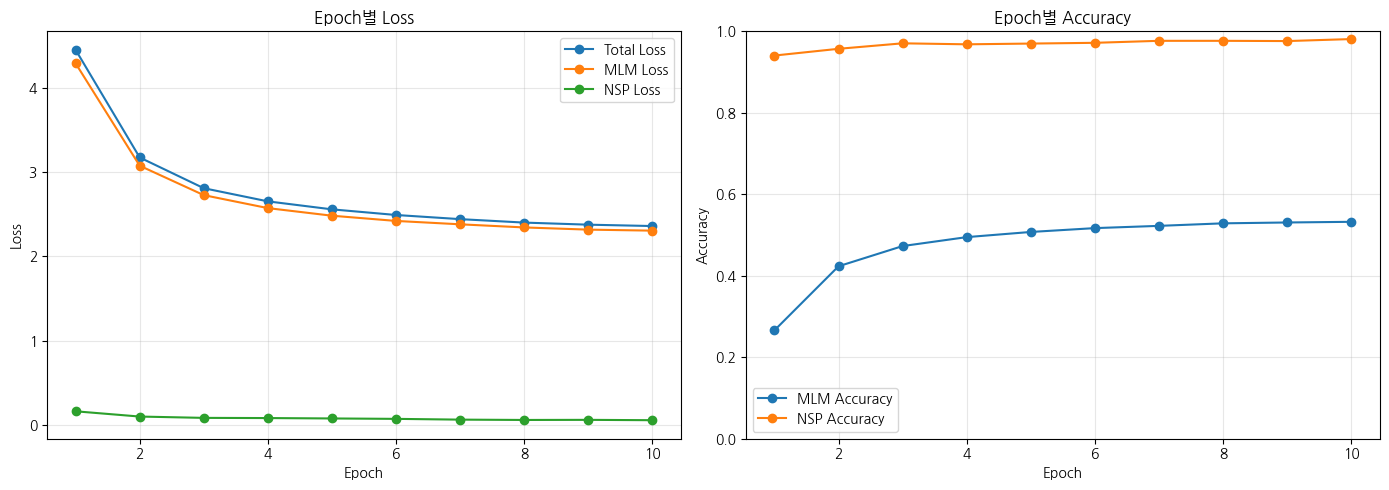

In [46]:
import matplotlib.pyplot as plt

epochs_range = range(1, num_epochs + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 왼쪽: Loss (전체, MLM, NSP)
axes[0].plot(epochs_range, full_history['loss'], marker='o', label='Total Loss')
axes[0].plot(epochs_range, full_history['mlm_loss'], marker='o', label='MLM Loss')
axes[0].plot(epochs_range, full_history['nsp_loss'], marker='o', label='NSP Loss')
axes[0].set_title('Epoch별 Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

# 오른쪽: Accuracy (MLM, NSP)
axes[1].plot(epochs_range, full_history['mlm_acc'], marker='o', label='MLM Accuracy')
axes[1].plot(epochs_range, full_history['nsp_acc'], marker='o', label='NSP Accuracy')
axes[1].set_title('Epoch별 Accuracy')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history_full.png', dpi=150)
plt.show()

MLM
- Loss가 4.5 → 2.3 정도로 줄었지만, 여전히 절대값이 높고 감소 폭이 완만하고 Accuracy도 약 53% 부근에서 정체
- 원인1 : hidden=256, layer=4의 크기가 작은 모델로 표현력이 제한적일 수 밖에 없음
- 원인2: 작은 mini 모델이라고 10 epoch이면 아주 작은 학습량이라 충분히 학습이 이루지지 못함

NSP
- NSP loss는 처음부터 낮고 감소가 미세한데 이것은 NSP T/F 문제(IsNext vs NotNext)로 랜덤으로 찍어도 50% accuracy가 나오는 구조이기 때문


In [50]:
model.eval()

def predict_masked_tokens(sentence, top_k=5):
    """
    문장을 넣으면 임의의 한 토큰을 [MASK]로 바꾸고,
    모델이 예측한 top-k 후보를 원래 정답과 함께 보여줌
    """
    token_ids = sp.encode_as_ids(sentence)
    input_ids = [CLS_ID] + token_ids + [SEP_ID]

    # 마스킹할 위치 하나 랜덤 선택 (CLS, SEP 제외)
    candidate_pos = list(range(1, len(input_ids) - 1))
    mask_pos = random.choice(candidate_pos)

    original_token = input_ids[mask_pos]
    input_ids_masked = input_ids.copy()
    input_ids_masked[mask_pos] = MASK_ID

    segment_ids = [0] * len(input_ids_masked)

    input_tensor = torch.tensor([input_ids_masked], dtype=torch.long).to(device)
    segment_tensor = torch.tensor([segment_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        mlm_logits, _ = model(input_tensor, segment_tensor)

    probs = F.softmax(mlm_logits[0, mask_pos], dim=-1)
    top_probs, top_ids = probs.topk(top_k)

    print(f"원문: {sentence}")
    print(f"마스킹된 토큰: '{sp.id_to_piece(original_token)}'")
    print(f"\nTop-{top_k} 예측:")
    for prob, tid in zip(top_probs, top_ids):
        marker = " <- 정답" if tid.item() == original_token else ""
        print(f"  {sp.id_to_piece(tid.item()):10s} ({prob.item()*100:.2f}%){marker}")


# 테스트 예시
predict_masked_tokens("나무위키는 다양한 정보를 담고 있는 위키 사이트입니다.")

원문: 나무위키는 다양한 정보를 담고 있는 위키 사이트입니다.
마스킹된 토큰: '▁나무'

Top-5 예측:
  ▁트         (10.84%)
  ▁위         (5.45%)
  ▁스         (3.84%)
  ▁          (2.53%)
  ▁바         (2.24%)


- MLM accuracy가 53%로 10문제 중 5번 정도 맞는 수준이라 성능면에서 많이 부족함을 잘 보여줌
- 예시의 정답 확률이 2.24~10.84% 낮은 수준이지만, Top 1의 확률(10.84)과 5위 균등분포(1/8000 voca_size=0.0125%)의 확률값은 거의 1000배 가까운 차이이며 따라서 모델이 답을 무작위로 찍었다기 보다는 학습을 한 흔적으로 볼 수 있음  
- 마스킹 된 토큰이 '나무'로 문장의 첫 단어로 아무런 문맥도 없는 상태에서 맞히는 것은 문장 중간의 단어를 맞히는 것보다 어려워서 정확도가 낮을 수 밖에 없었다고 봄

In [51]:
def predict_nsp(sent_a, sent_b):
    """
    두 문장을 넣으면 모델이 실제로 이어지는 문장인지(IsNext) 예측
    """
    tokens_a = sp.encode_as_ids(sent_a)
    tokens_b = sp.encode_as_ids(sent_b)

    input_ids = [CLS_ID] + tokens_a + [SEP_ID] + tokens_b + [SEP_ID]
    segment_ids = [0] * (len(tokens_a) + 2) + [1] * (len(tokens_b) + 1)

    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)
    segment_tensor = torch.tensor([segment_ids], dtype=torch.long).to(device)

    with torch.no_grad():
        _, nsp_logits = model(input_tensor, segment_tensor)

    probs = F.softmax(nsp_logits[0], dim=-1)
    is_next_prob = probs[1].item()      # IsNext(True)일 확률
    not_next_prob = probs[0].item()     # NotNext(False)일 확률

    print(f"문장 A: {sent_a}")
    print(f"문장 B: {sent_b}")
    print(f"\nIsNext 확률   : {is_next_prob*100:.2f}%")
    print(f"NotNext 확률  : {not_next_prob*100:.2f}%")
    print(f"예측 결과     : {'다음 문장 맞음 (True)' if is_next_prob > 0.5 else '관련 없는 문장 (False)'}")
    print("-" * 50)


# ===== 테스트 예시 =====

print("=" * 50)
print("NSP 테스트")
print("=" * 50)

# Case 1: 실제로 자연스럽게 이어지는 문장 쌍 (True 기대)
predict_nsp(
    "나무위키는 다양한 정보를 담고 있는 위키 사이트입니다.",
    "이 사이트는 많은 사용자들이 자유롭게 편집에 참여할 수 있습니다."
)

# Case 2: 서로 관련 없는 문장 쌍 (False 기대)
predict_nsp(
    "나무위키는 다양한 정보를 담고 있는 위키 사이트입니다.",
    "오늘 저녁 메뉴는 김치찌개로 정했다."
)

# Case 3: 추가 예시 - 이어지는 문장
predict_nsp(
    "대한민국의 수도는 서울특별시이다.",
    "서울은 정치, 경제, 문화의 중심지 역할을 하고 있다."
)

# Case 4: 추가 예시 - 관련 없는 문장
predict_nsp(
    "대한민국의 수도는 서울특별시이다.",
    "고양이는 하루에 12시간 이상 잠을 잔다."
)

NSP 테스트
문장 A: 나무위키는 다양한 정보를 담고 있는 위키 사이트입니다.
문장 B: 이 사이트는 많은 사용자들이 자유롭게 편집에 참여할 수 있습니다.

IsNext 확률   : 99.99%
NotNext 확률  : 0.01%
예측 결과     : 다음 문장 맞음 (True)
--------------------------------------------------
문장 A: 나무위키는 다양한 정보를 담고 있는 위키 사이트입니다.
문장 B: 오늘 저녁 메뉴는 김치찌개로 정했다.

IsNext 확률   : 40.26%
NotNext 확률  : 59.74%
예측 결과     : 관련 없는 문장 (False)
--------------------------------------------------
문장 A: 대한민국의 수도는 서울특별시이다.
문장 B: 서울은 정치, 경제, 문화의 중심지 역할을 하고 있다.

IsNext 확률   : 99.98%
NotNext 확률  : 0.02%
예측 결과     : 다음 문장 맞음 (True)
--------------------------------------------------
문장 A: 대한민국의 수도는 서울특별시이다.
문장 B: 고양이는 하루에 12시간 이상 잠을 잔다.

IsNext 확률   : 3.34%
NotNext 확률  : 96.66%
예측 결과     : 관련 없는 문장 (False)
--------------------------------------------------


[회고]
-  이 과제를 진행하며 pretrain task(MLM/NSP)의 난이도를 loss , accuracy, 예시를 통해 명확히 배울 수 있었음
-  MLM 모델에서 Loss/accuracy 그래프의 정체를 보면서 혹시 학습이 되지 않았는지 우려함. 이 부분을 생성형 ai와 대화하며 TOP5 확률분포를 균등분포와 비교하고 유의미한 학습이 이루어진 것을 확인한 과정이 오늘 학습에서 의미가 있었음